In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv("../data/HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6.0,18.0,11.0,"2,484",14.0
1,2025-12-18,11.0,50.0,6.0,"2,472",16.0
2,2025-12-17,7.0,31.0,11.0,"2,481",10.0
3,2025-12-16,8.0,54.0,15.0,"2,468",9.0
4,2025-12-15,11.0,42.0,9.0,"2,470",7.0


In [8]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [9]:
df.fillna(method='ffill', inplace=True)
df.head()

C:\Users\maazs\AppData\Local\Temp\ipykernel_21260\2766238617.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6.0,18.0,11.0,"2,484",14.0
1,2025-12-18,11.0,50.0,6.0,"2,472",16.0
2,2025-12-17,7.0,31.0,11.0,"2,481",10.0
3,2025-12-16,8.0,54.0,15.0,"2,468",9.0
4,2025-12-15,11.0,42.0,9.0,"2,470",7.0


In [10]:
df.columns = [
    'date',
    'cbp_apprehended',
    'cbp_custody',
    'cbp_transferred',
    'hhs_care',
    'hhs_discharged'
]

In [13]:
df.dtypes

date               datetime64[ns]
cbp_apprehended           float64
cbp_custody               float64
cbp_transferred           float64
hhs_care                   object
hhs_discharged            float64
dtype: object

In [14]:
df['hhs_care'].unique()

array(['2,484', '2,472', '2,481', '2,468', '2,470', '2,462', '2,437',
       '2,439', '2,443', '2,440', '2,429', '2,418', '2,419', '2,407',
       '2,410', '2,415', '2,389', '2,375', '2,371', '2,340', '2,345',
       '2,343', '2,317', '2,302', '2,294', '2,264', '2,272', '2,270',
       '2,269', '2,277', '2,287', '2,280', '2,286', '2,282', '2,276',
       '2,266', '2,261', '2,251', '2,243', '2,237', '2,233', '2,225',
       '2,235', '2,223', '2,192', '2,189', '2,187', '2,180', '2,164',
       '2,163', '2,159', '2,148', '2,146', '2,132', '2,138', '2,145',
       '2,141', '2,134', '2,096', '2,095', '2,086', '2,083', '2,047',
       '2,025', '2,023', '2,026', '2,015', '2,019', '2,020', '2,010',
       '1,984', '1,988', '1,989', '1,980', '1,981', '1,972', '1,983',
       '1,985', '1,991', '1,994', '1,997', '1,999', '2,006', '2,031',
       '2,036', '2,042', '2,040', '2,049', '2,058', '2,063', '2,072',
       '2,080', '2,088', '2,111', '2,117', '2,121', '2,153', '2,171',
       '2,181', '2,2

In [15]:
df['hhs_care'] = df['hhs_care'].str.replace(',', '', regex=False)
df['hhs_care'] = pd.to_numeric(df['hhs_care'])

In [16]:
df['transfer_efficiency'] = (
    df['cbp_transferred'] / df['cbp_custody']
)

In [17]:
df['discharge_effectiveness'] = (
    df['hhs_discharged'] / df['hhs_care']
)

In [18]:
df['throughput_rate'] = (
    df['hhs_discharged'] /
    df['cbp_apprehended']
)

In [19]:
df['backlog_rate'] = (
    df['cbp_apprehended'] -
    df['hhs_discharged']
)

In [20]:
df.describe()

C:\Users\maazs\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,date,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged,transfer_efficiency,discharge_effectiveness,throughput_rate,backlog_rate
count,1170,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000
mean,2023-12-11 01:32:18.461538304,70.245299,125.919658,92.257265,6255.400000,274.404274,0.671976,0.040147,inf,-204.158974
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000,0.000000,0.000000,0.000000,-447.000000
25%,2023-01-12 00:00:00,33.000000,53.000000,34.000000,6009.250000,154.000000,0.641509,0.023775,1.500000,-403.000000
50%,2023-08-07 12:00:00,33.000000,53.000000,34.000000,6566.000000,290.500000,0.641509,0.035628,3.500000,-167.500000
75%,2024-10-13 18:00:00,115.000000,220.000000,169.000000,7277.750000,436.000000,0.750000,0.066403,13.212121,-21.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000,2.300000,0.066403,inf,121.000000
std,NaN,64.138328,114.655390,89.154653,2235.387914,161.410400,0.244163,0.023242,NaN,175.057430


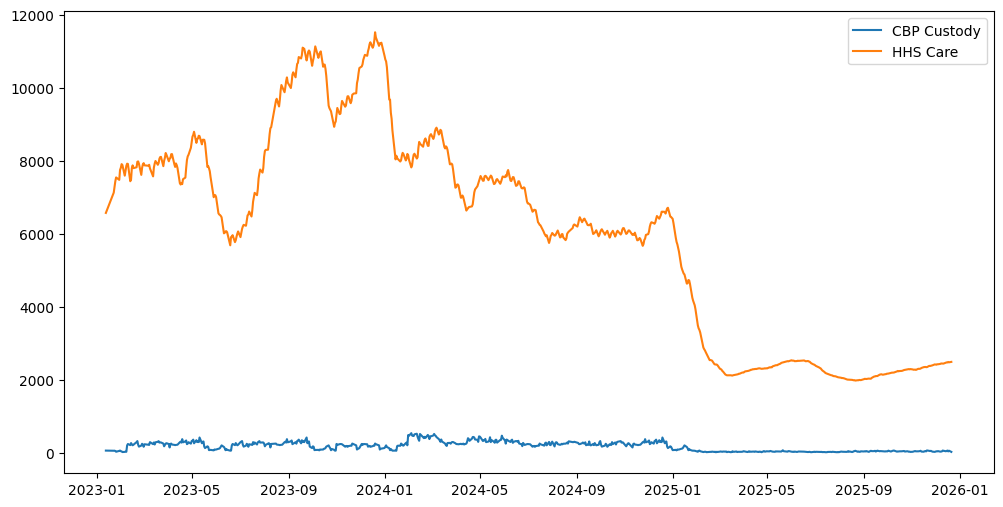

In [21]:
plt.figure(figsize=(12,6))

plt.plot(df['date'], df['cbp_custody'])
plt.plot(df['date'], df['hhs_care'])

plt.legend(['CBP Custody','HHS Care'])
plt.show()

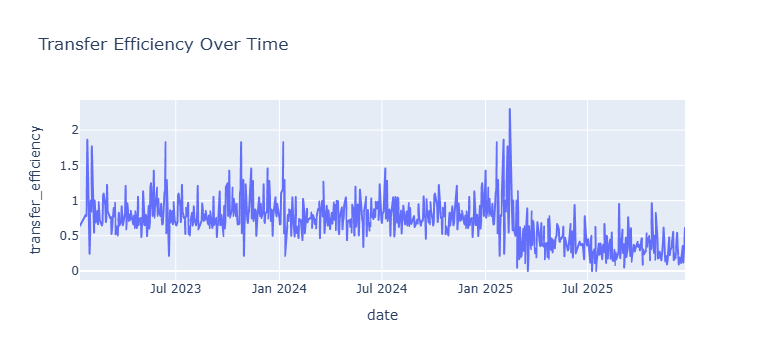

In [22]:
fig = px.line(
    df,
    x='date',
    y='transfer_efficiency',
    title='Transfer Efficiency Over Time'
)

fig.show()

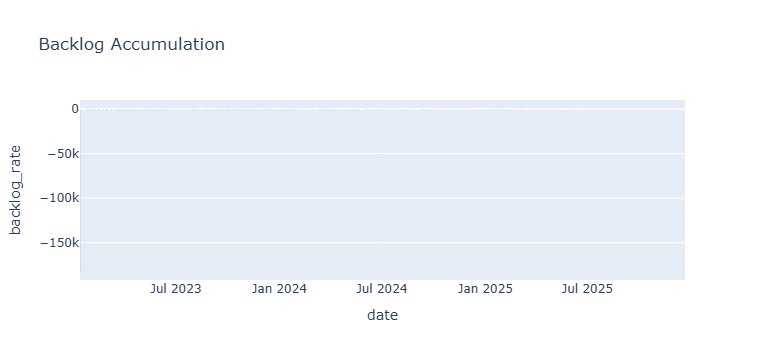

In [23]:
fig = px.bar(
    df,
    x='date',
    y='backlog_rate',
    title='Backlog Accumulation'
)

fig.show()